In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("cardekho.csv")

In [3]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [5]:
df = df.dropna().reset_index(drop=True)

In [6]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [7]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [8]:
df = df.drop("Unnamed: 0",axis=1)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  str    
 1   brand              15411 non-null  str    
 2   model              15411 non-null  str    
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  str    
 6   fuel_type          15411 non-null  str    
 7   transmission_type  15411 non-null  str    
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), str(6)
memory usage: 1.5 MB


In [10]:
df.shape

(15411, 13)

In [11]:
categoric = [col for col in df.columns if df[col].dtype == "str"]

In [12]:
categoric

['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

In [13]:
df[categoric].nunique()

car_name             121
brand                 32
model                120
seller_type            3
fuel_type              5
transmission_type      2
dtype: int64

In [14]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='str')

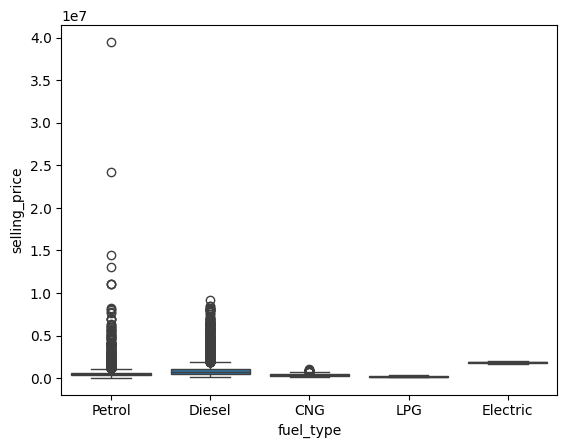

In [15]:
sns.boxplot(x=df["fuel_type"] , y=df["selling_price"])
plt.show()

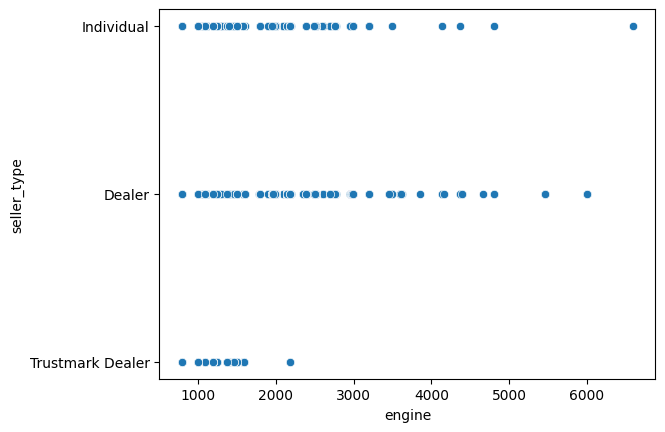

In [16]:
sns.scatterplot(x=df["engine"] , y=df["seller_type"])
plt.show()

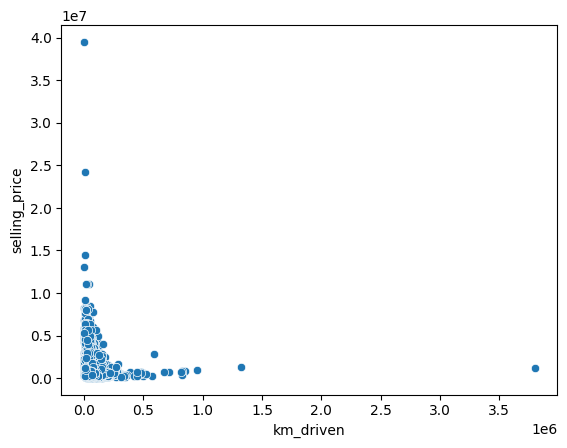

In [17]:
sns.scatterplot(x=df["km_driven"],y=df["selling_price"])
plt.show()

In [18]:
df.shape

(15411, 13)

In [19]:
df = df[df["selling_price"] < 2000000]

In [20]:
df.shape

(14605, 13)

In [21]:
df = df[df["km_driven"] < 1000000]

In [22]:
df.shape

(14603, 13)

In [23]:
df = df.drop_duplicates(keep="first" , ignore_index=True)

In [24]:
df.shape

(14448, 13)

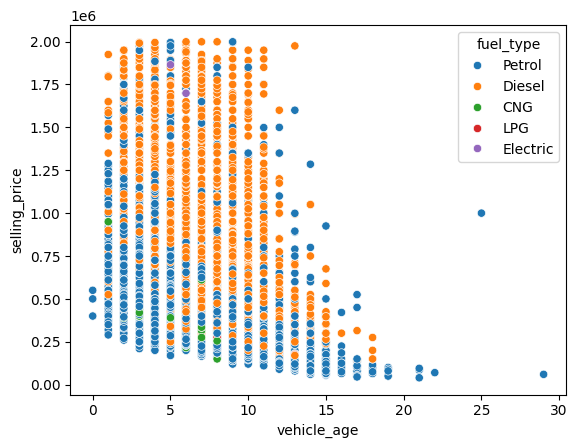

In [25]:
sns.scatterplot(x=df["vehicle_age"] , y=df["selling_price"] , hue= df["fuel_type"])
plt.show()

In [26]:
df = df[df["vehicle_age"] < 20]

In [27]:
df.shape

(14442, 13)

In [28]:
categoric

['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

In [29]:
df[categoric].nunique()

car_name             97
brand                25
model                97
seller_type           3
fuel_type             5
transmission_type     2
dtype: int64

In [30]:
# car_name , brand , model --> frequency
# seller_type , fuel_type , transmission_type --> onehotencoder

In [31]:
from sklearn.preprocessing import OneHotEncoder

In [32]:
onehot = OneHotEncoder(handle_unknown="ignore" , sparse_output=False)

In [33]:
onehot_columns = ["seller_type" , "fuel_type" , "transmission_type"]
freq_columns = ["car_name" , "brand" , "model"]

In [34]:
X = df.drop("selling_price" , axis=1)
y = df["selling_price"]

In [35]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [36]:
for col in freq_columns:
    freq = X_train[col].value_counts(normalize = True)

    X_train[col] = X_train[col].map(freq)
    X_test[col] = X_test[col].map(freq)
for col in freq_columns:
    X_test[col] = X_test[col].fillna(0)

In [37]:
X_train_enc = onehot.fit_transform(X_train[onehot_columns])
X_test_enc = onehot.transform(X_test[onehot_columns])

In [38]:
X_train_final = pd.concat([X_train.drop(columns=onehot_columns) , pd.DataFrame(X_train_enc , index=X_train.index).add_prefix("enc")] , axis=1)
X_test_final = pd.concat([X_test.drop(columns=onehot_columns) , pd.DataFrame(X_test_enc , index=X_test.index).add_prefix("enc")] , axis=1)

In [39]:
from sklearn.metrics import r2_score

In [40]:
from sklearn.ensemble import RandomForestRegressor

In [41]:
random = RandomForestRegressor(max_depth=12)

In [42]:
random.fit(X_train_final,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [43]:
y_pred = random.predict(X_test_final)

In [44]:
r2_score(y_test,y_pred)

0.9121205956212531